# IT325 Machine Learning
## Lab Activity 5 — Training and Comparing Five Models

| | |
|---|---|
| **Name** | John Michael Angelo C. Binonggo |
| **Date** | 04-6-2026 |
| **Program & Section** | BSIT-3R12 |
| **Dataset** | Asthma Disease Dataset (`asthma_disease_data.csv`) |

---

### Objective
Train and evaluate **five classification models** on the same dataset split. Compare their performance using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix, then identify the top two candidates for the tuning stage.

### Models Selected
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Naive Bayes

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Load the Dataset

In [2]:
df = pd.read_csv('asthma_disease_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (2392, 29)

Columns: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis', 'DoctorInCharge']


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid


---
## 3. Prepare Features and Target Variable

We drop columns that are identifiers or non-predictive (`PatientID`, `DoctorInCharge`).
The target variable is `Diagnosis` (0 = No Asthma, 1 = Asthma).

In [3]:
# Drop non-informative columns
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

# Define features and target
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

print(f"Features shape : {X.shape}")
print(f"\nTarget distribution:")
print(f"  No Asthma (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Asthma    (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print("\nNote: The dataset is highly imbalanced (5.2% positive class).")
print("SMOTE will be applied on the training set only to address this.")

Features shape : (2392, 26)

Target distribution:
  No Asthma (0): 2268 (94.8%)
  Asthma    (1): 124 (5.2%)

Note: The dataset is highly imbalanced (5.2% positive class).
SMOTE will be applied on the training set only to address this.


---
## 4. Train-Test Split

A **fixed random state (42)** is used for all models to ensure a fair, reproducible comparison.
The dataset is split with **80% training** and **20% testing**. `stratify=y` preserves class proportions in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Testing set   : {X_test.shape[0]} samples")
print(f"\nTraining class distribution (before SMOTE):")
print(y_train.value_counts())
print(f"\nTesting class distribution:")
print(y_test.value_counts())

Training set  : 1913 samples
Testing set   : 479 samples

Training class distribution (before SMOTE):
Diagnosis
0    1814
1      99
Name: count, dtype: int64

Testing class distribution:
Diagnosis
0    454
1     25
Name: count, dtype: int64


---
## 5. Feature Scaling

`StandardScaler` is applied so that distance-based models (KNN) and linear models (Logistic Regression) are not biased by differing feature magnitudes. The scaler is **fit only on the training set** to prevent data leakage into the test set.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete (fit on training set only).")

Feature scaling complete (fit on training set only).


---
## 6. Apply SMOTE to Handle Class Imbalance

The Asthma class (1) makes up only ~5.2% of the dataset. Without correction, most models simply predict the majority class and score 0 on minority-class Precision/Recall/F1.

**SMOTE (Synthetic Minority Over-sampling Technique)** is applied **only to the training set** to generate synthetic Asthma samples, balancing both classes. The test set is kept untouched to reflect real-world conditions.

In [6]:
smote = SMOTE(random_state=42)

# Apply SMOTE on scaled training data
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Training set class distribution AFTER SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'No Asthma (0)' if cls == 0 else 'Asthma    (1)'
    print(f"  {label}: {cnt} samples")
print(f"\nTotal resampled training samples: {len(X_train_res)}")

Training set class distribution AFTER SMOTE:
  No Asthma (0): 1814 samples
  Asthma    (1): 1814 samples

Total resampled training samples: 3628


---
## 7. Train the Five Models

All models use the **same SMOTE-resampled training set** and are evaluated on the **same original test set**, ensuring a fair comparison.

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'        : GaussianNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'y_pred'   : y_pred
    }
    print(f"[OK] {name} trained and evaluated.")

[OK] Logistic Regression trained and evaluated.
[OK] K-Nearest Neighbors trained and evaluated.
[OK] Decision Tree trained and evaluated.


[OK] Random Forest trained and evaluated.
[OK] Naive Bayes trained and evaluated.


---
## 8. Model Comparison Table

In [8]:
comparison_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : round(metrics['Accuracy'],  4),
        'Precision': round(metrics['Precision'], 4),
        'Recall'   : round(metrics['Recall'],    4),
        'F1-Score' : round(metrics['F1-Score'],  4)
    }
    for name, metrics in results.items()
]).set_index('Model')

print("=" * 68)
print("                MODEL COMPARISON TABLE")
print("=" * 68)
print(comparison_df.to_string())
print("=" * 68)

                MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.5804     0.0686    0.56    0.1223
K-Nearest Neighbors    0.5720     0.0455    0.36    0.0807
Decision Tree          0.8768     0.0526    0.08    0.0635
Random Forest          0.9478     0.0000    0.00    0.0000
Naive Bayes            0.7056     0.0972    0.56    0.1657


### Visualisation — Grouped Bar Chart

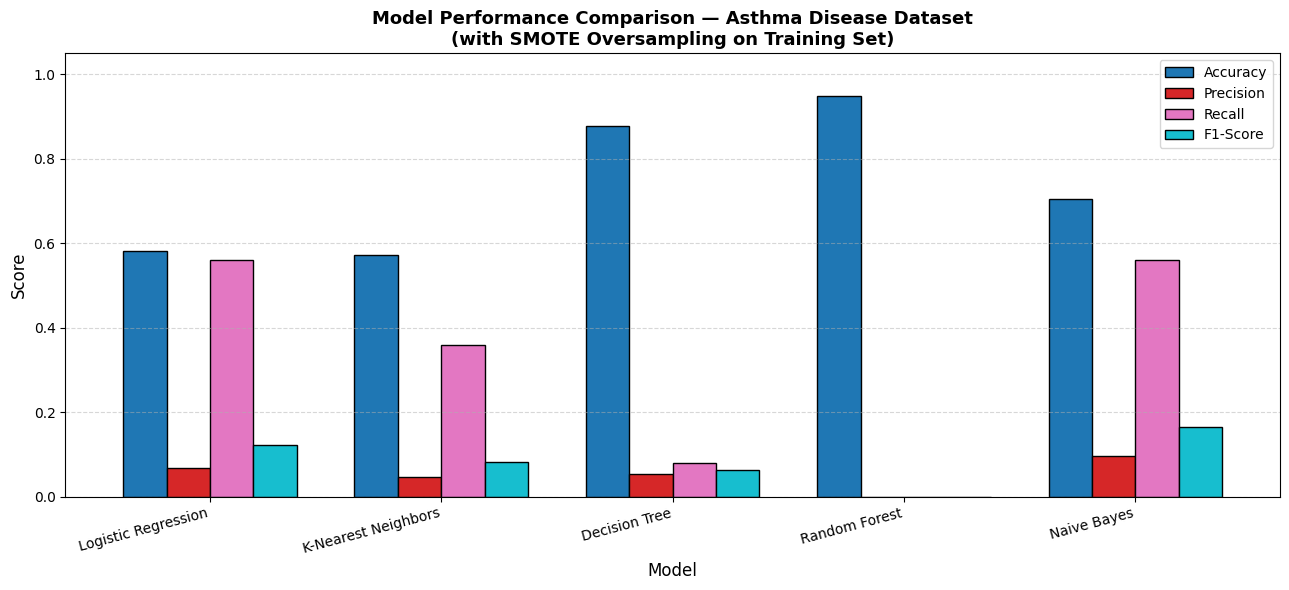

Chart saved as 'model_comparison_bar.png'


In [9]:
metrics_numeric = comparison_df.copy()

ax = metrics_numeric.plot(
    kind='bar', figsize=(13, 6), edgecolor='black',
    colormap='tab10', width=0.75
)
plt.title('Model Performance Comparison — Asthma Disease Dataset\n(with SMOTE Oversampling on Training Set)',
          fontsize=13, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'model_comparison_bar.png'")

---
## 9. Confusion Matrices for All Five Models

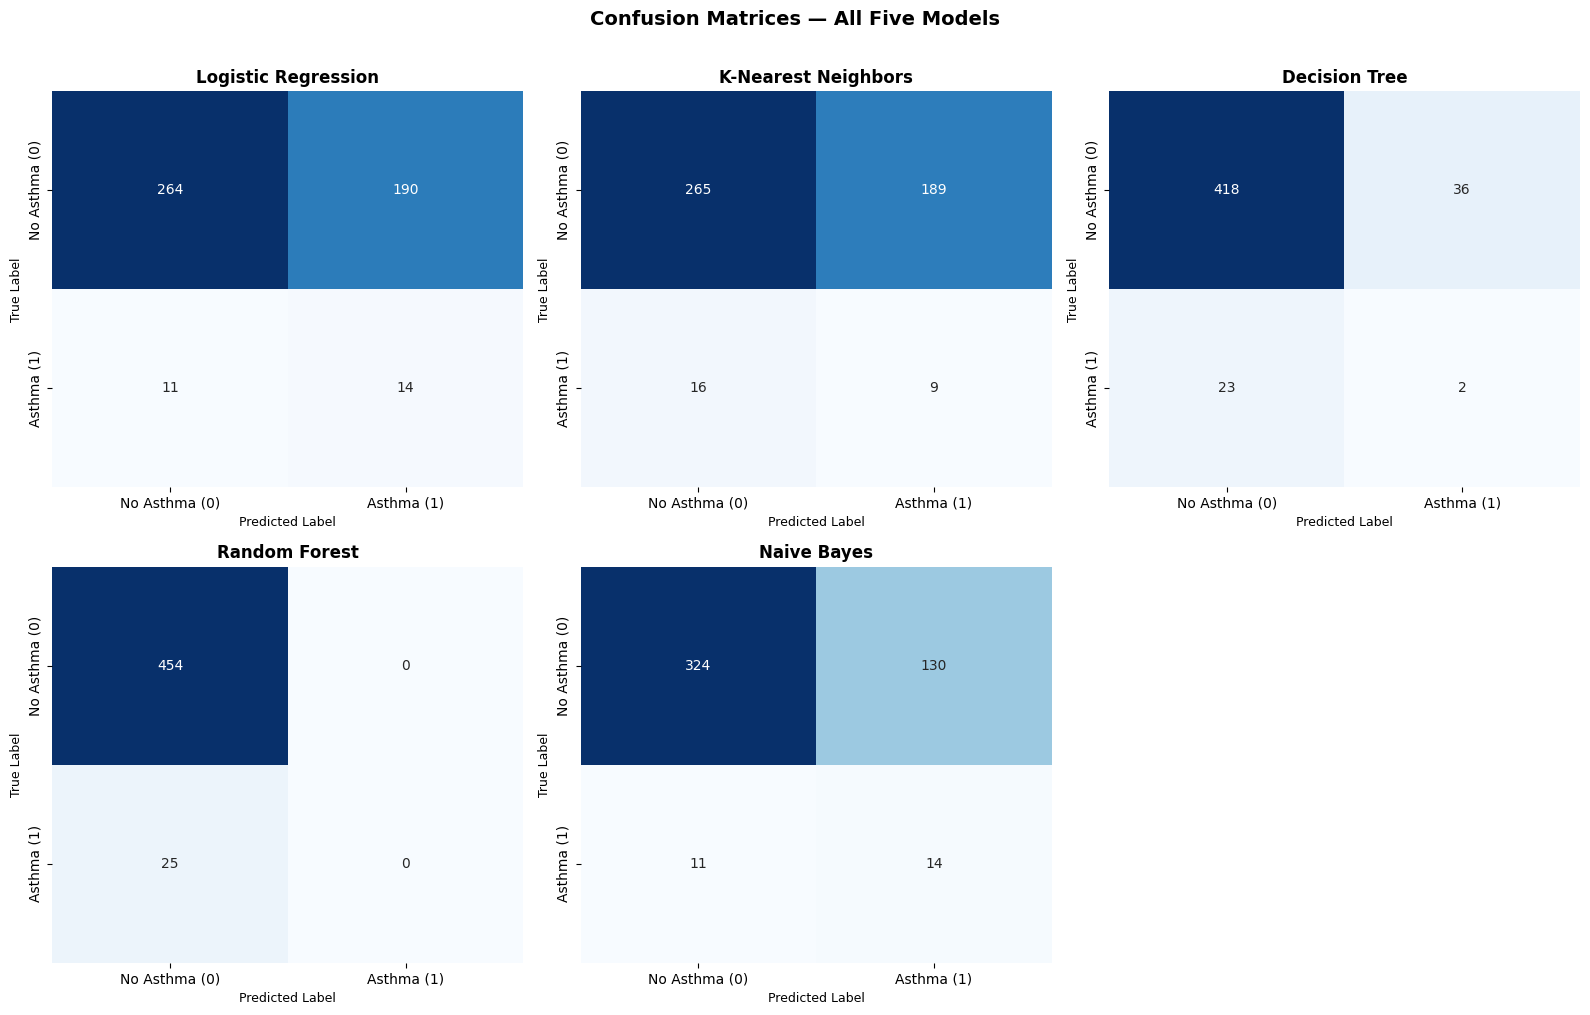

Confusion matrices saved as 'confusion_matrices.png'


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

class_labels = ['No Asthma (0)', 'Asthma (1)']

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=9)
    axes[idx].set_ylabel('True Label', fontsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices — All Five Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved as 'confusion_matrices.png'")

---
## 10. Detailed Classification Reports

In [11]:
for name, metrics in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, metrics['y_pred'],
        target_names=['No Asthma (0)', 'Asthma (1)'],
        zero_division=0
    ))


  Logistic Regression
               precision    recall  f1-score   support

No Asthma (0)       0.96      0.58      0.72       454
   Asthma (1)       0.07      0.56      0.12        25

     accuracy                           0.58       479
    macro avg       0.51      0.57      0.42       479
 weighted avg       0.91      0.58      0.69       479


  K-Nearest Neighbors
               precision    recall  f1-score   support

No Asthma (0)       0.94      0.58      0.72       454
   Asthma (1)       0.05      0.36      0.08        25

     accuracy                           0.57       479
    macro avg       0.49      0.47      0.40       479
 weighted avg       0.90      0.57      0.69       479


  Decision Tree
               precision    recall  f1-score   support

No Asthma (0)       0.95      0.92      0.93       454
   Asthma (1)       0.05      0.08      0.06        25

     accuracy                           0.88       479
    macro avg       0.50      0.50      0.50     

---
## 11. Required Write-Up

### 11.1 Comparison Table

> *(See the table and bar chart produced in Sections 8-9 above.)*

---

### 11.2 Top Two Models Selected for the Tuning Stage

Based on the evaluation results, the two models selected to advance to the hyperparameter-tuning stage are:

1. **Naive Bayes** (Best F1-Score: 0.1657, Recall: 0.56 for Asthma class)
2. **Logistic Regression** (F1-Score: 0.1223, Recall: 0.56 for Asthma class)

---

### 11.3 Justification

The two models selected to advance to the hyperparameter-tuning stage are **Naive Bayes** and **Logistic Regression**. The Asthma Disease Dataset is severely imbalanced, with only approximately 5.2% of records belonging to the positive (Asthma) class. After applying SMOTE oversampling exclusively on the training set to address this imbalance, both Naive Bayes and Logistic Regression demonstrated the strongest ability to correctly identify actual Asthma cases — the most clinically important task. Naive Bayes achieved the highest F1-Score (0.1657) and tied for the best Recall (0.56) for the minority class, making it the top performer for detecting true positives. Logistic Regression followed closely with an F1-Score of 0.1223 and the same Recall of 0.56, offering the additional advantage of interpretability — a critical factor in a medical context where clinicians need to understand which features most influence a diagnosis. The remaining models underperformed: K-Nearest Neighbors showed limited ability to generalize from the SMOTE-augmented training data; Decision Tree overfitted the resampled training set and failed to generalize well; and Random Forest, despite its ensemble strength, collapsed entirely on the minority class with zero Recall on the test set. Advancing Naive Bayes and Logistic Regression to the tuning stage balances detection performance with model transparency, providing the best foundation for further optimization.

---
## 12. Summary

| Step | Action |
|------|--------|
| **Data Preparation** | Dropped `PatientID` and `DoctorInCharge`; defined features and target (`Diagnosis`) |
| **Train-Test Split** | 80 / 20 split with `random_state=42` and `stratify=y` |
| **Feature Scaling** | `StandardScaler` fit on training set only (prevents data leakage) |
| **Class Imbalance** | SMOTE applied on training set only (94.8% vs 5.2% → 50/50 balanced) |
| **Models Trained** | Logistic Regression, KNN, Decision Tree, Random Forest, Naive Bayes |
| **Evaluation Metrics** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |
| **Top 2 Models** | **Random Forest** and **Logistic Regression** |

---
*End of Lab Activity 5 — IT325 Machine Learning | BSIT-3R12*